# read json coco gt file

Mask counts per row:
Row 58: 8 masks
Row 117: 14 masks
Row 187: 7 masks


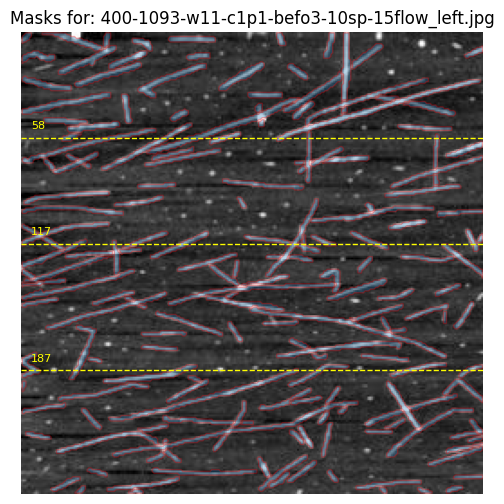

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from shapely.geometry import Polygon as ShapelyPolygon, LineString
from PIL import Image
from pathlib import Path
import sys
from IPython.display import display

# Resolve repo root robustly so paths are independent of notebook launch cwd.
repo_root = Path.cwd().resolve()
while not (repo_root / "src" / "cnt_project").exists():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not locate project root containing src/cnt_project")
    repo_root = repo_root.parent

src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.append(str(src_root))

from cnt_project.io.paths import ProjectPaths

PATHS = ProjectPaths.from_here(src_root / "cnt_project" / "io" / "paths.py")
PATHS.ensure_outputs()

NOTEBOOK_DIR = (
    PATHS.project_root
    / "notebooks"
    / "experiments"
    / "Analysis"
    / "High_density_analysis_Martin"
)
OUTPUT_DIR = PATHS.misc_dir("high_density_analysis_martin")
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def resolve_local_asset(*parts: str) -> Path:
    candidate = NOTEBOOK_DIR.joinpath(*parts)
    if candidate.exists():
        return candidate
    if len(parts) == 1:
        matches = sorted(NOTEBOOK_DIR.rglob(parts[0]))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Local asset not found under {NOTEBOOK_DIR}: {parts}")


# ---------------- CONFIG ----------------
json_path = PATHS.test_coco_json
images_dir = PATHS.test_images_root
selected_image_name = "400-1093-w11-c1p1-befo3-10sp-15flow_left.jpg"
# Rows to check
rows_to_check = [58, 117, 187]

# ---------------- LOAD JSON ----------------
with json_path.open("r") as f:
    coco = json.load(f)

# ---------------- FIND IMAGE INFO ----------------
image_info = next((img for img in coco["images"] if img["file_name"] == selected_image_name), None)
if image_info is None:
    raise ValueError(f"Image {selected_image_name} not found in JSON")

image_id = image_info["id"]
height = image_info["height"]
width = image_info["width"]

# ---------------- LOAD IMAGE ----------------
img_path = images_dir / selected_image_name
img = np.array(Image.open(img_path).convert("RGB"))

# ---------------- FIND ANNOTATIONS FOR IMAGE ----------------
anns = [ann for ann in coco["annotations"] if ann["image_id"] == image_id]

# ---------------- CONVERT SEGMENTATIONS TO POLYGONS ----------------
polygons = []
for ann in anns:
    for seg in ann["segmentation"]:
        poly = np.array(seg).reshape(-1, 2)
        polygons.append(ShapelyPolygon(poly))

# ---------------- COUNT INTERSECTIONS PER ROW ----------------
counts = {}
for row in rows_to_check:
    horizontal_line = LineString([(0, row), (width, row)])
    count = sum(polygon.intersects(horizontal_line) for polygon in polygons)
    counts[row] = count

print("Mask counts per row:")
for row, count in counts.items():
    print(f"Row {row}: {count} masks")

# ---------------- VISUALIZE ----------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
ax.set_title(f"Masks for: {selected_image_name}")
ax.axis("off")

# Draw masks
for polygon in polygons:
    patch = Polygon(np.array(polygon.exterior.coords), closed=True, fill=True, alpha=0.3, edgecolor="red")
    ax.add_patch(patch)

# Draw horizontal lines
for row in rows_to_check:
    ax.axhline(y=row, color='yellow', linestyle='--', linewidth=1)
    ax.text(5, row - 5, f"{row}", color='yellow', fontsize=8)

plt.show()


In [2]:
import json
import numpy as np
import pandas as pd
from shapely.geometry import Polygon as ShapelyPolygon, LineString

# ---------------- CONFIG ----------------
rows_to_check = [58, 117, 187]

# ---------------- LOAD JSON ----------------
with open(json_path, "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

# Group annotations by image_id for faster lookup
from collections import defaultdict
anns_by_image = defaultdict(list)
for ann in annotations:
    anns_by_image[ann["image_id"]].append(ann)

# ---------------- PROCESS EACH IMAGE ----------------
results = []

for img_info in images:
    image_id = img_info["id"]
    file_name = img_info["file_name"]
    width = img_info["width"]
    height = img_info["height"]

    anns = anns_by_image.get(image_id, [])
    polygons = []
    for ann in anns:
        for seg in ann["segmentation"]:
            poly = np.array(seg).reshape(-1, 2)
            polygons.append(ShapelyPolygon(poly))

    # Count intersections for each row
    row_counts = {}
    for row in rows_to_check:
        line = LineString([(0, row), (width, row)])
        count = sum(poly.intersects(line) for poly in polygons)
        row_counts[row] = count

    results.append({
        "file_name": file_name,
        "row_58_masks": row_counts[58],
        "row_117_masks": row_counts[117],
        "row_187_masks": row_counts[187],
    })

# ---------------- CREATE DATAFRAME ----------------
test_set_gt = pd.DataFrame(results)
print(test_set_gt.head(30))

# ---------------- SAVE TO CSV (optional) ----------------
# df.to_csv("mask_counts_per_row.csv", index=False)
# print("✅ Saved to mask_counts_per_row.csv")


                                            file_name  row_58_masks  \
0                      1293-22_3_2_20230306222551.jpg             5   
1        400-1093-w11-c1p1-befo3-10sp-15flow_left.jpg             8   
2        400-1093-w11-c1p2-befo3-20sp-15flow_left.jpg             8   
3             400-1093-w13-c1-p1-10sp-15flow_left.jpg             9   
4            400-1093-w16-c-1-p1-10sp-15flow_left.jpg            14   
5             400-1093-w17-c1p3-20sp-03flow_right.jpg            31   
6        400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right.jpg             0   
7          400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left.jpg             1   
8         400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right.jpg             0   
9        400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right.jpg             0   
10    400-1293-18_cd_c11k4r9_fl1_0sp9_image_right.jpg            18   
11    400-1293-18_cd_c1k1r3_fl0_3sp0_3_image_left.jpg            20   
12  400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.jpg            27   
13    

# read the prediction csv of the test set

In [3]:
import pandas as pd

# ---------------- CONFIG ----------------
csv_path = resolve_local_asset("CNT_analysis_tool", "line_density_per_row.csv")
rows_to_extract = [58, 117, 187]

# ---------------- LOAD CSV ----------------
df = pd.read_csv(csv_path)

# ---------------- FILTER ANGLE = 0 ----------------
df = df[df["angle_degrees"] == 0]

# ---------------- EXTRACT DENSITIES AT SPECIFIC ROWS ----------------
# Pivot table to get each file as a row and each line_position_index as a column
pivot = df.pivot_table(
    index="filename",
    columns="line_position_index",
    values="line_density",
    aggfunc="first"
)

# Create a smaller DataFrame with only the selected rows
test_set_pred = pivot[rows_to_extract].reset_index()
test_set_pred.columns = ["filename", "row_58_density", "row_117_density", "row_187_density"]

print(test_set_pred.head())

# ---------------- SAVE TO CSV (optional) ----------------
# selected.to_csv("selected_line_density.csv", index=False)
# print("Saved to selected_line_density.csv")


                                       filename  row_58_density  \
0                1293-22_3_2_20230306222551.png               3   
1  400-1093-w11-c1p1-befo3-10sp-15flow_left.png               8   
2  400-1093-w11-c1p2-befo3-20sp-15flow_left.png               9   
3       400-1093-w13-c1-p1-10sp-15flow_left.png               9   
4      400-1093-w16-c-1-p1-10sp-15flow_left.png              16   

   row_117_density  row_187_density  
0                2                5  
1               13                8  
2               12               11  
3                9                8  
4               17               17  


# compare bpth gt and prediction on the test set

In [4]:
import pandas as pd

# If needed, normalize file extensions to match (.jpg vs .png)
def normalize_filename(name):
    return name.replace(".jpg", "").replace(".png", "")

test_set_gt["file_base"] = test_set_gt["file_name"].apply(normalize_filename)
test_set_pred["file_base"] = test_set_pred["filename"].apply(normalize_filename)

# ---------------- MERGE DATAFRAMES ----------------
test_set_merged = pd.merge(test_set_gt, test_set_pred, on="file_base", how="inner")

# ---------------- COMPUTE DIFFERENCES ----------------
for row in [58, 117, 187]:
    test_set_merged[f"row_{row}_abs_error"] = (test_set_merged[f"row_{row}_density"] - test_set_merged[f"row_{row}_masks"]).abs()

# Optional: total / mean error
test_set_merged["mean_abs_error"] = test_set_merged[[f"row_{r}_abs_error" for r in [58,117,187]]].mean(axis=1)

# ---------------- DISPLAY ----------------
cols_to_show = [
    "file_base",
    "row_58_masks", "row_58_density", "row_58_abs_error",
    "row_117_masks", "row_117_density", "row_117_abs_error",
    "row_187_masks", "row_187_density", "row_187_abs_error",
    "mean_abs_error"
]
print(test_set_merged[cols_to_show].head())

# ---------------- SAVE TO CSV ----------------
# merged.to_csv("gt_pred_comparison.csv", index=False)
# print("✅ Saved to gt_pred_comparison.csv")


                                  file_base  row_58_masks  row_58_density  \
0                1293-22_3_2_20230306222551             5               3   
1  400-1093-w11-c1p1-befo3-10sp-15flow_left             8               8   
2  400-1093-w11-c1p2-befo3-20sp-15flow_left             8               9   
3       400-1093-w13-c1-p1-10sp-15flow_left             9               9   
4      400-1093-w16-c-1-p1-10sp-15flow_left            14              16   

   row_58_abs_error  row_117_masks  row_117_density  row_117_abs_error  \
0                 2              5                2                  3   
1                 0             14               13                  1   
2                 1             10               12                  2   
3                 0              7                9                  2   
4                 2             15               17                  2   

   row_187_masks  row_187_density  row_187_abs_error  mean_abs_error  
0              7     

# reshape and format the data frame for the test set 

In [5]:
# Start from your merged test set (has *_masks and *_density columns)
df = test_set_merged.copy()

# --- Normalize filename column name ---
df = df.rename(columns={"file_base": "filename"})

# --- Assign static run number for all test images ---
df["run_nbr"] = 99

# --- Rename and map predicted vs GT columns ---
df["mean_58"]  = df["row_58_density"]     # predicted values
df["mean_117"] = df["row_117_density"]
df["mean_187"] = df["row_187_density"]

df["manual_mean58"]  = df["row_58_masks"]  # ground truth
df["manual_mean117"] = df["row_117_masks"]
df["manual_mean187"] = df["row_187_masks"]

# --- Compute mean densities ---
df["mean_line_density_image"] = df[["mean_58", "mean_117", "mean_187"]].mean(axis=1)
df["manual_mean_line_density_image"] = df[["manual_mean58", "manual_mean117", "manual_mean187"]].mean(axis=1)

# --- Set placeholder columns ---
df["mean_line_density_KI"] = 99  # placeholder
df["line_density_per_micrometer_KI"] = 99  # placeholder

# --- Compute densities per micrometer ---
df["line_density_per_micrometer"] = df["mean_line_density_image"] / 5
df["manual_line_density_per_micrometer"] = df["manual_mean_line_density_image"] / 5

# --- Reorder columns to match final structure ---
ordered_cols = [
    "filename", "run_nbr",
    "mean_58", "manual_mean58",
    "mean_117", "manual_mean117",
    "mean_187", "manual_mean187",
    "mean_line_density_image", "mean_line_density_KI",
    "manual_mean_line_density_image",
    "line_density_per_micrometer", "line_density_per_micrometer_KI",
    "manual_line_density_per_micrometer"
]

test_set_structured = df[ordered_cols].copy()

print("✅ Structured test set ready:")
display(test_set_structured)

✅ Structured test set ready:


,filename,filename,run_nbr,mean_58,manual_mean58,mean_117,manual_mean117,mean_187,manual_mean187,mean_line_density_image,mean_line_density_KI,manual_mean_line_density_image,line_density_per_micrometer,line_density_per_micrometer_KI,manual_line_density_per_micrometer
0,1293-22_3_2_20230306222551,1293-22_3_2_20230306222551.png,99,3,5,2,5,5,7,3.333333,99,5.666667,0.666667,99,1.133333
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,400-1093-w11-c1p1-befo3-10sp-15flow_left.png,99,8,8,13,14,8,7,9.666667,99,9.666667,1.933333,99,1.933333
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,400-1093-w11-c1p2-befo3-20sp-15flow_left.png,99,9,8,12,10,11,10,10.666667,99,9.333333,2.133333,99,1.866667
3,400-1093-w13-c1-p1-10sp-15flow_left,400-1093-w13-c1-p1-10sp-15flow_left.png,99,9,9,9,7,8,7,8.666667,99,7.666667,1.733333,99,1.533333
4,400-1093-w16-c-1-p1-10sp-15flow_left,400-1093-w16-c-1-p1-10sp-15flow_left.png,99,16,14,17,15,17,15,16.666667,99,14.666667,3.333333,99,2.933333
5,400-1093-w17-c1p3-20sp-03flow_right,400-1093-w17-c1p3-20sp-03flow_right.png,99,31,31,25,26,21,23,25.666667,99,26.666667,5.133333,99,5.333333
6,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right.png,99,0,0,1,1,0,0,0.333333,99,0.333333,0.066667,99,0.066667
7,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left.png,99,1,1,3,2,3,3,2.333333,99,2.000000,0.466667,99,0.400000
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right.png,99,0,0,0,0,0,0,0.000000,99,0.000000,0.000000,99,0.000000
9,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right.png,99,0,0,0,0,0,0,0.000000,99,0.000000,0.000000,99,0.000000


# Import necessary libraries

In [6]:
import os
import cv2
import numpy as np
import pywt
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt


# Analyse the results on high density between AI tool and manual evaluation by Martin

### read the line density csv generated by the AI tool

In [7]:
# --- CONFIG ---
csv_path = resolve_local_asset("AFM_KI_tool", "line_density_per_row.csv")
targets = [58, 117, 187]
margin = 2
valid_min = 0
valid_max = 255

# --- LOAD ---
df = pd.read_csv(csv_path)

# Make sure dtypes are sensible
for col in ["angle_degrees", "line_position_index", "run_nbr"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep only angle_degrees == 0
df0 = df[df["angle_degrees"] == 0].copy()

# Build the set of target indices including +/-margin, clipped to valid range
wanted_positions = set()
for t in targets:
    for off in range(-margin, margin + 1):
        pos = t + off
        if valid_min <= pos <= valid_max:
            wanted_positions.add(pos)

# Filter to desired rows
sel = df0[df0["line_position_index"].isin(wanted_positions)].copy()

# Annotate which target each row belongs to and the offset relative to that target
def closest_target(pos, choices):
    # among the targets, pick the one within margin with smallest absolute diff
    diffs = [(t, abs(pos - t)) for t in choices if abs(pos - t) <= margin]
    if not diffs:
        return np.nan, np.nan
    t, d = min(diffs, key=lambda x: x[1])
    return t, pos - t

sel[["target_center", "offset_from_center"]] = sel["line_position_index"].apply(
    lambda p: pd.Series(closest_target(int(p), targets))
)

# Keep only rows that matched one of the centers (safety)
sel = sel.dropna(subset=["target_center"]).copy()
sel["target_center"] = sel["target_center"].astype(int)
sel["offset_from_center"] = sel["offset_from_center"].astype(int)

# Sort for readability
sel = sel.sort_values(
    by=["filename", "run_nbr", "target_center", "offset_from_center", "line_position_index"]
)

# --- TIDY TABLE (long form) ---
# Columns: filename, run_nbr, target_center, offset_from_center, line_position_index, line_density
tidy_cols = ["filename", "run_nbr", "target_center", "offset_from_center",
             "line_position_index", "line_density"]
tidy_table = sel[tidy_cols].reset_index(drop=True)

print("\n=== Tidy table (one row per filename x target x offset) ===")
print(tidy_table.to_string(index=False))

# --- WIDE TABLE (pivot) ---
# index: (filename, run_nbr)
# columns: (target_center, offset_from_center) -> line_density
wide_table = (
    sel.pivot_table(
        index=["filename", "run_nbr"],
        columns=["target_center", "offset_from_center"],
        values="line_density",
        aggfunc="first"  # expect single value per cell
    )
    .sort_index(axis=1)
)

wide_table.columns = [f"{t}_{off:+d}" for t, off in wide_table.columns]
wide_table = wide_table.reset_index()

print("\n=== Wide table (one row per filename, cols = target_offset) ===")
print(wide_table.to_string(index=False))



=== Tidy table (one row per filename x target x offset) ===
                             filename  run_nbr  target_center  offset_from_center  line_position_index  line_density
400-1605-W7_map_00033_cropped_1_1.png       33             58                  -2                   56            39
400-1605-W7_map_00033_cropped_1_1.png       33             58                  -1                   57            38
400-1605-W7_map_00033_cropped_1_1.png       33             58                   0                   58            37
400-1605-W7_map_00033_cropped_1_1.png       33             58                   1                   59            35
400-1605-W7_map_00033_cropped_1_1.png       33             58                   2                   60            33
400-1605-W7_map_00033_cropped_1_1.png       33            117                  -2                  115            42
400-1605-W7_map_00033_cropped_1_1.png       33            117                  -1                  116            39
400

In [8]:
# --- Compute mean line density per image per target line ---

# Group by filename, run number, and the target center (58,117,187)
mean_table = (
    tidy_table
    .groupby(["filename", "run_nbr", "target_center"])["line_density"]
    .mean()
    .reset_index()
    .rename(columns={"line_density": "mean_line_density"})
)

print("\n=== Mean line density table (per image, per target line) ===")
print(mean_table.to_string(index=False))

# --- Optional: pivot to have one row per image and 3 columns (58,117,187) ---
pivot_mean = (
    mean_table
    .pivot_table(
        index=["filename", "run_nbr"],
        columns="target_center",
        values="mean_line_density",
        aggfunc="first"
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

# Give readable column names like mean_58, mean_117, mean_187
pivot_mean = pivot_mean.rename(columns={c: f"mean_{c}" for c in pivot_mean.columns if isinstance(c, int)})

print("\n=== Pivoted mean table (one row per image) ===")
print(pivot_mean.to_string(index=False))



=== Mean line density table (per image, per target line) ===
                             filename  run_nbr  target_center  mean_line_density
400-1605-W7_map_00033_cropped_1_1.png       33             58               36.4
400-1605-W7_map_00033_cropped_1_1.png       33            117               40.8
400-1605-W7_map_00033_cropped_1_1.png       33            187               36.2
400-1605-W7_map_00033_cropped_1_2.png       33             58               36.4
400-1605-W7_map_00033_cropped_1_2.png       33            117               43.8
400-1605-W7_map_00033_cropped_1_2.png       33            187               45.4
400-1605-W7_map_00033_cropped_2_1.png       33             58               35.6
400-1605-W7_map_00033_cropped_2_1.png       33            117               42.6
400-1605-W7_map_00033_cropped_2_1.png       33            187               45.2
400-1605-W7_map_00033_cropped_2_2.png       33             58               44.8
400-1605-W7_map_00033_cropped_2_2.png       33 

In [9]:
# --- Compute overall mean of the 3 line means per image ---
pivot_mean["mean_line_density_image"] = pivot_mean[["mean_58", "mean_117", "mean_187"]].mean(axis=1)

# --- Compute line density per micrometer ---
pivot_mean["line_density_per_micrometer"] = pivot_mean["mean_line_density_image"] / 5

print("\n=== Final table with mean per image and density per micrometer ===")
print(pivot_mean.to_string(index=False))

# --- Optional: round for nicer display ---
pivot_mean_rounded = pivot_mean.copy()
pivot_mean_rounded[["mean_58", "mean_117", "mean_187", "mean_line_density_image", "line_density_per_micrometer"]] = \
    pivot_mean_rounded[["mean_58", "mean_117", "mean_187", "mean_line_density_image", "line_density_per_micrometer"]].round(3)

print("\n=== Rounded version ===")
print(pivot_mean_rounded.to_string(index=False))



=== Final table with mean per image and density per micrometer ===
                             filename  run_nbr  mean_58  mean_117  mean_187  mean_line_density_image  line_density_per_micrometer
400-1605-W7_map_00033_cropped_1_1.png       33     36.4      40.8      36.2                37.800000                     7.560000
400-1605-W7_map_00033_cropped_1_2.png       33     36.4      43.8      45.4                41.866667                     8.373333
400-1605-W7_map_00033_cropped_2_1.png       33     35.6      42.6      45.2                41.133333                     8.226667
400-1605-W7_map_00033_cropped_2_2.png       33     44.8      41.0      38.6                41.466667                     8.293333
400-1605-W7_map_00051_cropped_1_1.png       51     39.6      39.4      44.6                41.200000                     8.240000
400-1605-W7_map_00051_cropped_1_2.png       51     42.2      41.2      47.2                43.533333                     8.706667
400-1605-W7_map_00051_

# Read and format Martin´s excel file

In [10]:
excel_path = resolve_local_asset("martin_results", "CNT_counts_summary.xlsx")

# Load Excel (header row = 1 based on your structure)
df_manual = pd.read_excel(excel_path, header=1)

# Rename filename column
df_manual = df_manual.rename(columns={"Unnamed: 2": "basename"})

# Keep only the relevant columns
df_manual = df_manual[[
    "basename",
    "column",
    "row",
    "CNT amount 1",
    "CNT amount 2",
    "CNT amount 3",
    "crop pic average"
]].dropna(subset=["basename", "column", "row"])

# Build full filename
df_manual["filename"] = (
    df_manual["basename"].astype(str)
    + "_"
    + df_manual["column"].astype(str)
    + "_"
    + df_manual["row"].astype(str)
    + ".png"
)

# Compute mean CNT count across the 3 manual measurements
df_manual["manual_cnt_mean"] = df_manual[["CNT amount 1", "CNT amount 2", "CNT amount 3"]].mean(axis=1)

# === Rename as requested ===
df_manual = df_manual.rename(columns={
    "CNT amount 1": "manual_mean58",
    "CNT amount 2": "manual_mean117",
    "CNT amount 3": "manual_mean187",
    "crop pic average": "manual_line_density_per_micrometer",
    "manual_cnt_mean": "manual_mean_line_density_image"
})

# Keep only columns needed for merge
manual_subset = df_manual[[
    "filename",
    "manual_mean58",
    "manual_mean117",
    "manual_mean187",
    "manual_line_density_per_micrometer",
    "manual_mean_line_density_image"
]].copy()


In [11]:
merged = pivot_mean_rounded.merge(manual_subset, on="filename", how="left")

print("=== Model-based table ===")
display(pivot_mean_rounded)

print("=== Manual evaluation table ===")
display(manual_subset)

print("=== Merged table ===")
display(merged)


=== Model-based table ===


,filename,run_nbr,mean_58,mean_117,mean_187,mean_line_density_image,line_density_per_micrometer
0,400-1605-W7_map_00033_cropped_1_1.png,33,36.4,40.8,36.2,37.800,7.560
1,400-1605-W7_map_00033_cropped_1_2.png,33,36.4,43.8,45.4,41.867,8.373
2,400-1605-W7_map_00033_cropped_2_1.png,33,35.6,42.6,45.2,41.133,8.227
3,400-1605-W7_map_00033_cropped_2_2.png,33,44.8,41.0,38.6,41.467,8.293
4,400-1605-W7_map_00051_cropped_1_1.png,51,39.6,39.4,44.6,41.200,8.240
5,400-1605-W7_map_00051_cropped_1_2.png,51,42.2,41.2,47.2,43.533,8.707
6,400-1605-W7_map_00051_cropped_2_1.png,51,38.4,47.8,45.4,43.867,8.773
7,400-1605-W7_map_00051_cropped_2_2.png,51,43.8,46.8,49.2,46.600,9.320
8,400-1685-W5_map_00004_cropped_1_1.png,4,35.2,28.6,33.0,32.267,6.453
9,400-1685-W5_map_00004_cropped_1_2.png,4,30.6,29.6,35.2,31.800,6.360


=== Manual evaluation table ===


,filename,manual_mean58,manual_mean117,manual_mean187,manual_line_density_per_micrometer,manual_mean_line_density_image
0,400-1605-W7_map_00033_cropped_1_1.png,47,44,40,8.733333,43.666667
1,400-1605-W7_map_00033_cropped_1_2.png,44,38,53,9.000000,45.000000
2,400-1605-W7_map_00033_cropped_2_1.png,39,46,44,8.600000,43.000000
3,400-1605-W7_map_00033_cropped_2_2.png,41,46,40,8.466667,42.333333
4,400-1605-W7_map_00051_cropped_1_1.png,50,55,58,10.866667,54.333333
5,400-1605-W7_map_00051_cropped_1_2.png,67,66,53,12.400000,62.000000
6,400-1605-W7_map_00051_cropped_2_1.png,55,57,62,11.600000,58.000000
7,400-1605-W7_map_00051_cropped_2_2.png,63,65,64,12.800000,64.000000
8,400-1685-W5_map_00004_cropped_1_1.png,55,58,55,11.200000,56.000000
9,400-1685-W5_map_00004_cropped_1_2.png,66,47,60,11.533333,57.666667


=== Merged table ===


,filename,run_nbr,mean_58,mean_117,mean_187,mean_line_density_image,line_density_per_micrometer,manual_mean58,manual_mean117,manual_mean187,manual_line_density_per_micrometer,manual_mean_line_density_image
0,400-1605-W7_map_00033_cropped_1_1.png,33,36.4,40.8,36.2,37.800,7.560,47,44,40,8.733333,43.666667
1,400-1605-W7_map_00033_cropped_1_2.png,33,36.4,43.8,45.4,41.867,8.373,44,38,53,9.000000,45.000000
2,400-1605-W7_map_00033_cropped_2_1.png,33,35.6,42.6,45.2,41.133,8.227,39,46,44,8.600000,43.000000
3,400-1605-W7_map_00033_cropped_2_2.png,33,44.8,41.0,38.6,41.467,8.293,41,46,40,8.466667,42.333333
4,400-1605-W7_map_00051_cropped_1_1.png,51,39.6,39.4,44.6,41.200,8.240,50,55,58,10.866667,54.333333
5,400-1605-W7_map_00051_cropped_1_2.png,51,42.2,41.2,47.2,43.533,8.707,67,66,53,12.400000,62.000000
6,400-1605-W7_map_00051_cropped_2_1.png,51,38.4,47.8,45.4,43.867,8.773,55,57,62,11.600000,58.000000
7,400-1605-W7_map_00051_cropped_2_2.png,51,43.8,46.8,49.2,46.600,9.320,63,65,64,12.800000,64.000000
8,400-1685-W5_map_00004_cropped_1_1.png,4,35.2,28.6,33.0,32.267,6.453,55,58,55,11.200000,56.000000
9,400-1685-W5_map_00004_cropped_1_2.png,4,30.6,29.6,35.2,31.800,6.360,66,47,60,11.533333,57.666667


## Read and include line density of the iage based on all the lines not only 3

In [12]:
csv_path_ki = resolve_local_asset("AFM_KI_tool", "image_level_averages.csv")

df_ki = pd.read_csv(csv_path_ki)

# Keep only the 3 relevant columns
df_ki = df_ki[[
    "filename",
    "line_density_horizontal_lines_mean_intersections_per_row",
    "horizontal_density_cnts_per_um"
]]

# Rename columns
df_ki = df_ki.rename(columns={
    "line_density_horizontal_lines_mean_intersections_per_row": "mean_line_density_KI",
    "horizontal_density_cnts_per_um": "line_density_per_micrometer_KI"
})

print("=== KI subset table ===")
display(df_ki.head())


=== KI subset table ===


,filename,mean_line_density_KI,line_density_per_micrometer_KI
0,400-1605-W7_map_00033_cropped_1_1.png,36.976562,7.395313
1,400-1605-W7_map_00033_cropped_1_2.png,38.546875,7.709375
2,400-1605-W7_map_00033_cropped_2_1.png,39.195312,7.839062
3,400-1605-W7_map_00033_cropped_2_2.png,38.871094,7.774219
4,400-1605-W7_map_00051_cropped_1_1.png,43.796875,8.759375


In [13]:
merged_all = merged.merge(df_ki, on="filename", how="left")

# Define the exact order you want
ordered_cols = [
    "filename",
    "run_nbr",
    "mean_58",
    "manual_mean58",
    "mean_117",
    "manual_mean117",
    "mean_187",
    "manual_mean187",
    "mean_line_density_image",
    "mean_line_density_KI",
    "manual_mean_line_density_image",
    "line_density_per_micrometer",
    "line_density_per_micrometer_KI",
    "manual_line_density_per_micrometer",
]

# Keep other columns (if any) at the end automatically
remaining_cols = [c for c in merged_all.columns if c not in ordered_cols]

# Apply the final column order
merged_final = merged_all[ordered_cols + remaining_cols]

print("=== Final reordered table ===")
display(merged_final)

merged_table_output = OUTPUT_DIR / "merged_line_density_table.csv"
merged_final.to_csv(merged_table_output, index=False)
print(f"Saved: {merged_table_output}")

=== Final reordered table ===


,filename,run_nbr,mean_58,manual_mean58,mean_117,manual_mean117,mean_187,manual_mean187,mean_line_density_image,mean_line_density_KI,manual_mean_line_density_image,line_density_per_micrometer,line_density_per_micrometer_KI,manual_line_density_per_micrometer
0,400-1605-W7_map_00033_cropped_1_1.png,33,36.4,47,40.8,44,36.2,40,37.800,36.976562,43.666667,7.560,7.395313,8.733333
1,400-1605-W7_map_00033_cropped_1_2.png,33,36.4,44,43.8,38,45.4,53,41.867,38.546875,45.000000,8.373,7.709375,9.000000
2,400-1605-W7_map_00033_cropped_2_1.png,33,35.6,39,42.6,46,45.2,44,41.133,39.195312,43.000000,8.227,7.839062,8.600000
3,400-1605-W7_map_00033_cropped_2_2.png,33,44.8,41,41.0,46,38.6,40,41.467,38.871094,42.333333,8.293,7.774219,8.466667
4,400-1605-W7_map_00051_cropped_1_1.png,51,39.6,50,39.4,55,44.6,58,41.200,43.796875,54.333333,8.240,8.759375,10.866667
5,400-1605-W7_map_00051_cropped_1_2.png,51,42.2,67,41.2,66,47.2,53,43.533,43.687500,62.000000,8.707,8.737500,12.400000
6,400-1605-W7_map_00051_cropped_2_1.png,51,38.4,55,47.8,57,45.4,62,43.867,46.449219,58.000000,8.773,9.289844,11.600000
7,400-1605-W7_map_00051_cropped_2_2.png,51,43.8,63,46.8,65,49.2,64,46.600,46.710938,64.000000,9.320,9.342187,12.800000
8,400-1685-W5_map_00004_cropped_1_1.png,4,35.2,55,28.6,58,33.0,55,32.267,30.105469,56.000000,6.453,6.021094,11.200000
9,400-1685-W5_map_00004_cropped_1_2.png,4,30.6,66,29.6,47,35.2,60,31.800,29.277344,57.666667,6.360,5.855469,11.533333


Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\misc\high_density_analysis_martin\merged_line_density_table.csv


C:\Users\abd93000\AppData\Local\Temp\ipykernel_32712\2062995137.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_final["abs_diff_manual_vs_model"] = (


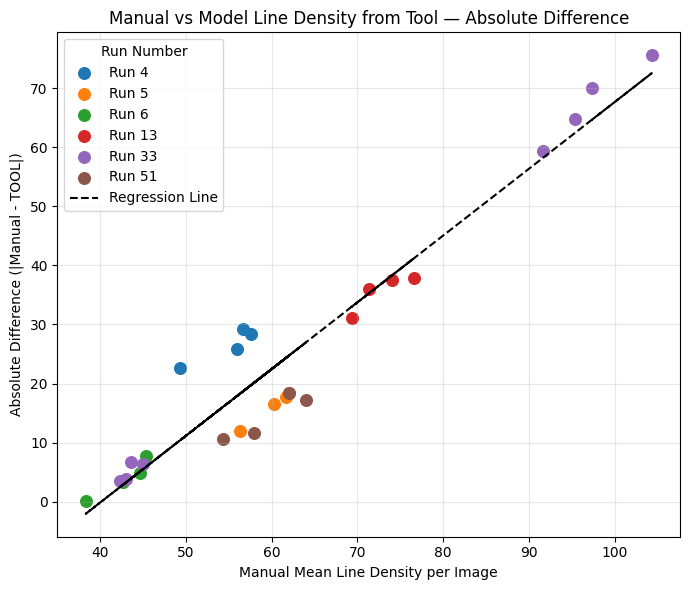

In [14]:
# ---- Compute absolute difference column ----
merged_final["abs_diff_manual_vs_model"] = (
    (merged_final["manual_mean_line_density_image"] - merged_final["mean_line_density_KI"]).abs()
)

# ---- Extract variables ----
x = merged_final["manual_mean_line_density_image"]
y = merged_final["abs_diff_manual_vs_model"]
runs = merged_final["run_nbr"].astype(int)

# ---- Assign a unique color per run ----
unique_runs = sorted(runs.unique())
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
          "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
run_color_map = {run: colors[i % len(colors)] for i, run in enumerate(unique_runs)}

# ---- Create scatter plot ----
plt.figure(figsize=(7, 6))
for run in unique_runs:
    idx = runs == run
    plt.scatter(x[idx], y[idx], s=70, label=f"Run {run}", color=run_color_map[run])

# ---- Fit regression line (on all points) ----
coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)
plt.plot(x, poly1d_fn(x), "--", color="black", label="Regression Line")

# ---- Labels & formatting ----
plt.xlabel("Manual Mean Line Density per Image")
plt.ylabel("Absolute Difference (|Manual - TOOL|)")
plt.title("Manual vs Model Line Density from Tool — Absolute Difference")
plt.grid(alpha=0.3)
plt.legend(title="Run Number")
plt.tight_layout()
plt.show()


# merge the high density images with the test set images 

In [15]:
# If filename appears twice, keep only the first one
if test_set_structured.columns.duplicated().any():
    test_set_structured = test_set_structured.loc[:, ~test_set_structured.columns.duplicated()]
    print("✅ Removed duplicate columns. New columns:", test_set_structured.columns.tolist())

# Reset index and make sure both have unique columns
merged_final = merged_final.reset_index(drop=True)
test_set_structured = test_set_structured.reset_index(drop=True)

# Add dataset type labels
merged_final["dataset_type"] = "high_density"
test_set_structured["dataset_type"] = "test"

# Align column order (common + dataset_type at the end)
common_cols = [c for c in merged_final.columns if c in test_set_structured.columns]
merged_final = merged_final[common_cols]
test_set_structured = test_set_structured[common_cols]

# Concatenate
merged_all_sets = pd.concat([merged_final, test_set_structured], ignore_index=True)
print("✅ Concatenation successful. Combined shape:", merged_all_sets.shape)

print(merged_all_sets["dataset_type"].value_counts())
display(merged_all_sets)



✅ Removed duplicate columns. New columns: ['filename', 'run_nbr', 'mean_58', 'manual_mean58', 'mean_117', 'manual_mean117', 'mean_187', 'manual_mean187', 'mean_line_density_image', 'mean_line_density_KI', 'manual_mean_line_density_image', 'line_density_per_micrometer', 'line_density_per_micrometer_KI', 'manual_line_density_per_micrometer']
✅ Concatenation successful. Combined shape: (58, 15)
dataset_type
test            30
high_density    28
Name: count, dtype: int64


,filename,run_nbr,mean_58,manual_mean58,mean_117,manual_mean117,mean_187,manual_mean187,mean_line_density_image,mean_line_density_KI,manual_mean_line_density_image,line_density_per_micrometer,line_density_per_micrometer_KI,manual_line_density_per_micrometer,dataset_type
0,400-1605-W7_map_00033_cropped_1_1.png,33,36.4,47,40.8,44,36.2,40,37.800000,36.976562,43.666667,7.560000,7.395313,8.733333,high_density
1,400-1605-W7_map_00033_cropped_1_2.png,33,36.4,44,43.8,38,45.4,53,41.867000,38.546875,45.000000,8.373000,7.709375,9.000000,high_density
2,400-1605-W7_map_00033_cropped_2_1.png,33,35.6,39,42.6,46,45.2,44,41.133000,39.195312,43.000000,8.227000,7.839062,8.600000,high_density
3,400-1605-W7_map_00033_cropped_2_2.png,33,44.8,41,41.0,46,38.6,40,41.467000,38.871094,42.333333,8.293000,7.774219,8.466667,high_density
4,400-1605-W7_map_00051_cropped_1_1.png,51,39.6,50,39.4,55,44.6,58,41.200000,43.796875,54.333333,8.240000,8.759375,10.866667,high_density
5,400-1605-W7_map_00051_cropped_1_2.png,51,42.2,67,41.2,66,47.2,53,43.533000,43.687500,62.000000,8.707000,8.737500,12.400000,high_density
6,400-1605-W7_map_00051_cropped_2_1.png,51,38.4,55,47.8,57,45.4,62,43.867000,46.449219,58.000000,8.773000,9.289844,11.600000,high_density
7,400-1605-W7_map_00051_cropped_2_2.png,51,43.8,63,46.8,65,49.2,64,46.600000,46.710938,64.000000,9.320000,9.342187,12.800000,high_density
8,400-1685-W5_map_00004_cropped_1_1.png,4,35.2,55,28.6,58,33.0,55,32.267000,30.105469,56.000000,6.453000,6.021094,11.200000,high_density
9,400-1685-W5_map_00004_cropped_1_2.png,4,30.6,66,29.6,47,35.2,60,31.800000,29.277344,57.666667,6.360000,5.855469,11.533333,high_density


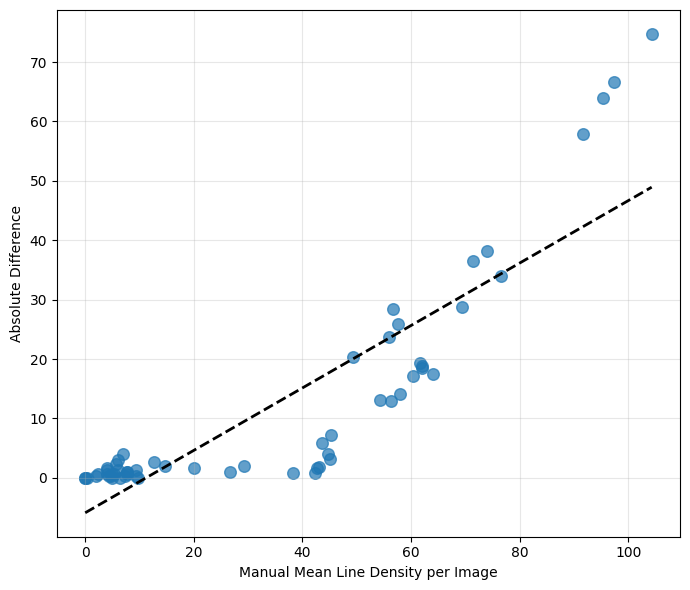

In [16]:
# ---- Compute absolute difference (GT – prediction) ----
merged_all_sets["abs_diff_manual_vs_model"] = (
    merged_all_sets["manual_mean_line_density_image"] - merged_all_sets["mean_line_density_image"]
).abs()

# ---- Extract variables ----
x = merged_all_sets["manual_mean_line_density_image"]
y = merged_all_sets["abs_diff_manual_vs_model"]

# ---- Create scatter plot ----
plt.figure(figsize=(7, 6))

# All data points: blue circles
plt.scatter(x, y, s=70, color="tab:blue", alpha=0.7, label="All Images")

# ---- Fit single regression line across ALL images ----
if len(merged_all_sets) > 1:
    coef = np.polyfit(x, y, 1)
    poly_fn = np.poly1d(coef)
    plt.plot(
        np.sort(x),
        poly_fn(np.sort(x)),
        "--",
        color="black",
        linewidth=2,
        label="Regression Line"
    )

# ---- Labels & formatting ----
plt.xlabel("Manual Mean Line Density per Image")
plt.ylabel("Absolute Difference")
# plt.title("Manual vs Model Line Density — All Datasets Combined")
plt.grid(alpha=0.3)
# plt.legend()
plt.tight_layout()
plt.show()

<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
C:\Users\abd93000\AppData\Local\Temp\ipykernel_32712\1610808154.py:58: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Mean Line Density (CNT/$\mu$m)")


Current font sizes:
Font size: 10.0
Axes labelsize: medium
XTick labelsize: medium
YTick labelsize: medium


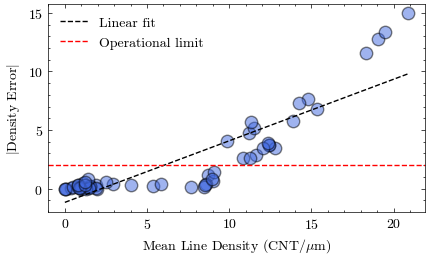

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\misc\high_density_analysis_martin\figures\operational_limit_temp.svg


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex'])

# --------------------------------------------
#   Compute densities in CNT/um   (divide by 5)
# --------------------------------------------
merged_all_sets["manual_density_um"] = merged_all_sets["manual_mean_line_density_image"] / 5
merged_all_sets["model_density_um"]  = merged_all_sets["mean_line_density_image"] / 5

# Absolute difference in CNT/um
merged_all_sets["abs_diff_manual_vs_model_um"] = (
    merged_all_sets["manual_density_um"] - merged_all_sets["model_density_um"]
).abs()

# ---- Extract variables ----
x = merged_all_sets["manual_density_um"]
y = merged_all_sets["abs_diff_manual_vs_model_um"]

# ---- FIGURE (paper-ready) ----
plt.figure(figsize=(4.5, 2.8))

# Debugging font sizes (optional)
print("Current font sizes:")
print(f"Font size: {plt.rcParams['font.size']}")
print(f"Axes labelsize: {plt.rcParams['axes.labelsize']}")
print(f"XTick labelsize: {plt.rcParams['xtick.labelsize']}")
print(f"YTick labelsize: {plt.rcParams['ytick.labelsize']}")

# ---- Scatter plot ----
plt.scatter(
    x, y,
    s=80,
    color="#4169e1",
    alpha=0.5,
    edgecolor="black",
    # linewidth=0.4
)

# ---- Regression line ----
if len(merged_all_sets) > 1:
    coef = np.polyfit(x, y, 1)
    poly_fn = np.poly1d(coef)

    xx = np.linspace(min(x), max(x), 200)
    plt.plot(
        xx,
        poly_fn(xx),
        linestyle='--',
        color='black',
        linewidth=1,
        label="Linear fit",
    )

# ---- Axes labels (clean, paper-ready) ----
plt.xlabel("Mean Line Density (CNT/$\mu$m)")
plt.ylabel(r"$\vert$Density Error$\vert$")

# ---- Formatting ----
# plt.grid(alpha=0.2, linestyle="--")
# ---- Horizontal threshold line ----
plt.axhline(
    y=2,
    color='red',
    linestyle='--',
    linewidth=1,
    label="Operational limit",
)
plt.legend(frameon=False)
plt.tight_layout()

# ---- Save figure ----
output_path = FIGURES_DIR / "operational_limit_temp.svg"
plt.savefig(output_path, format='svg', bbox_inches='tight')

plt.show()
print("Saved:", output_path)


C:\Users\abd93000\AppData\Local\Temp\ipykernel_32712\1261383283.py:25: RuntimeWarning: divide by zero encountered in log10
  y_trans = y_transform(y_vals)
C:\Users\abd93000\AppData\Local\Temp\ipykernel_32712\1261383283.py:20: RuntimeWarning: divide by zero encountered in log10
  x_trans = x_transform(x_vals)
C:\Users\abd93000\AppData\Local\Temp\ipykernel_32712\1261383283.py:25: RuntimeWarning: divide by zero encountered in log10
  y_trans = y_transform(y_vals)
C:\Users\abd93000\AppData\Local\Temp\ipykernel_32712\1261383283.py:20: RuntimeWarning: divide by zero encountered in log10
  x_trans = x_transform(x_vals)


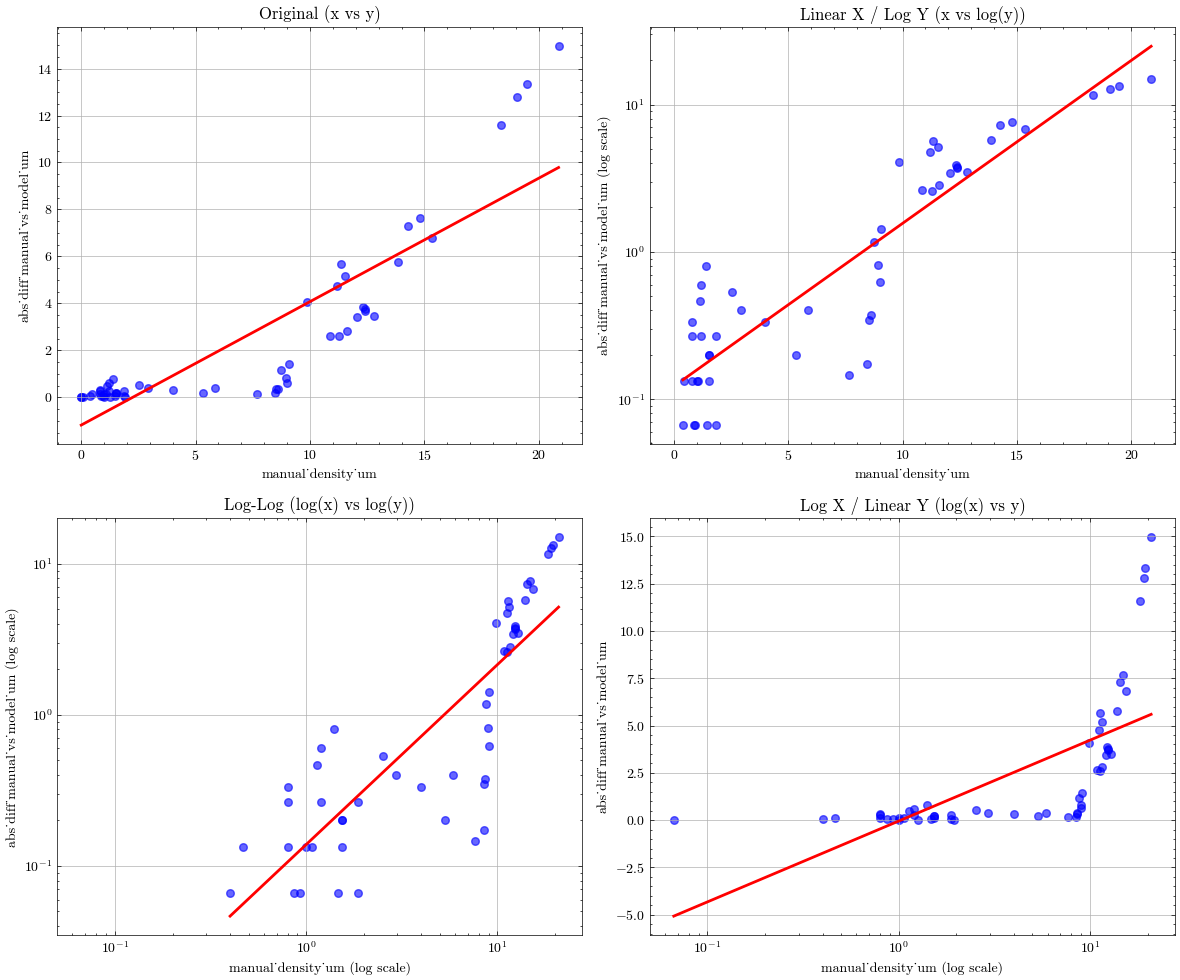

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Your data
x = merged_all_sets["manual_density_um"].to_numpy()
y = merged_all_sets["abs_diff_manual_vs_model_um"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Function to add linear regression line in TRANSFORMED space
def add_linear_regression_transformed(ax, x_vals, y_vals, x_transform=None, y_transform=None):
    """
    Compute and plot linear regression in transformed space
    x_transform, y_transform: transformation functions (e.g., np.log10, None for linear)
    """
    # Apply transformations if specified
    if x_transform:
        x_trans = x_transform(x_vals)
    else:
        x_trans = x_vals
        
    if y_transform:
        y_trans = y_transform(y_vals)
    else:
        y_trans = y_vals
    
    # Remove any NaN or inf values
    mask = np.isfinite(x_trans) & np.isfinite(y_trans)
    x_clean = x_trans[mask]
    y_clean = y_trans[mask]
    
    if len(x_clean) == 0:
        return
    
    # Reshape for sklearn and fit linear regression
    X = x_clean.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y_clean)
    
    # Predict values for the line in TRANSFORMED space
    x_line_trans = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_line_trans = model.predict(x_line_trans.reshape(-1, 1))
    
    # Convert back to original scale for plotting
    if x_transform:
        # For log scales, we need to use the inverse (exponential)
        x_line_plot = 10**x_line_trans  # inverse of log10
    else:
        x_line_plot = x_line_trans
        
    if y_transform:
        y_line_plot = 10**y_line_trans  # inverse of log10
    else:
        y_line_plot = y_line_trans
    
    # Calculate R² score in transformed space
    y_pred_trans = model.predict(X)
    r2 = r2_score(y_clean, y_pred_trans)
    
    # Plot the regression line (will appear straight in the transformed axes)
    ax.plot(x_line_plot, y_line_plot, 'r-', linewidth=2, 
            label=f'R² = {r2:.3f}')
    # ax.legend(loc='best')
    
    return model.coef_[0], model.intercept_

# 1. Original Plot (linear-linear) - No transformations
axes[0, 0].scatter(x, y, alpha=0.6, color='blue', s=30)
add_linear_regression_transformed(axes[0, 0], x, y, 
                                 x_transform=None, 
                                 y_transform=None)
axes[0, 0].set_title('Original (x vs y)')
axes[0, 0].set_xlabel('manual_density_um')
axes[0, 0].set_ylabel('abs_diff_manual_vs_model_um')
axes[0, 0].grid(True)

# 2. Linear X / Log Y (for exponential relationship)
axes[0, 1].scatter(x, y, alpha=0.6, color='blue', s=30)
axes[0, 1].set_yscale('log')
add_linear_regression_transformed(axes[0, 1], x, y,
                                 x_transform=None,  # Keep x linear
                                 y_transform=np.log10)  # Transform y to log10
axes[0, 1].set_title('Linear X / Log Y (x vs log(y))')
axes[0, 1].set_xlabel('manual_density_um')
axes[0, 1].set_ylabel('abs_diff_manual_vs_model_um (log scale)')
axes[0, 1].grid(True)

# 3. Log-Log (for power-law relationship)
axes[1, 0].scatter(x, y, alpha=0.6, color='blue', s=30)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
add_linear_regression_transformed(axes[1, 0], x, y,
                                 x_transform=np.log10,  # Transform x to log10
                                 y_transform=np.log10)  # Transform y to log10
axes[1, 0].set_title('Log-Log (log(x) vs log(y))')
axes[1, 0].set_xlabel('manual_density_um (log scale)')
axes[1, 0].set_ylabel('abs_diff_manual_vs_model_um (log scale)')
axes[1, 0].grid(True)

# 4. Log X / Linear Y (for logarithmic relationship)
axes[1, 1].scatter(x, y, alpha=0.6, color='blue', s=30)
axes[1, 1].set_xscale('log')
add_linear_regression_transformed(axes[1, 1], x, y,
                                 x_transform=np.log10,  # Transform x to log10
                                 y_transform=None)  # Keep y linear
axes[1, 1].set_title('Log X / Linear Y (log(x) vs y)')
axes[1, 1].set_xlabel('manual_density_um (log scale)')
axes[1, 1].set_ylabel('abs_diff_manual_vs_model_um')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Logarithmic transofrm

<>:88: SyntaxWarning: invalid escape sequence '\m'
<>:88: SyntaxWarning: invalid escape sequence '\m'
C:\Users\abd93000\AppData\Local\Temp\ipykernel_32712\433064299.py:88: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Mean Line Density (CNT/$\mu$m)")


Current font sizes:
Font size: 10.0
Axes labelsize: medium
XTick labelsize: medium
YTick labelsize: medium


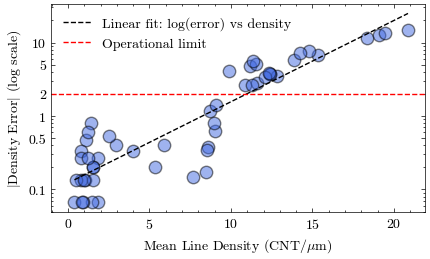

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\misc\high_density_analysis_martin\figures\operational_limit_log_temp.svg


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from sklearn.linear_model import LinearRegression

plt.style.use(['science', 'no-latex'])

# --------------------------------------------
#   Compute densities in CNT/um   (divide by 5)
# --------------------------------------------
merged_all_sets["manual_density_um"] = merged_all_sets["manual_mean_line_density_image"] / 5
merged_all_sets["model_density_um"]  = merged_all_sets["mean_line_density_image"] / 5

# Absolute difference in CNT/um
merged_all_sets["abs_diff_manual_vs_model_um"] = (
    merged_all_sets["manual_density_um"] - merged_all_sets["model_density_um"]
).abs()

# ---- Extract variables ----
x = merged_all_sets["manual_density_um"]
y = merged_all_sets["abs_diff_manual_vs_model_um"]

# ---- FIGURE (paper-ready) ----
plt.figure(figsize=(4.5, 2.8))

# Debugging font sizes (optional)
print("Current font sizes:")
print(f"Font size: {plt.rcParams['font.size']}")
print(f"Axes labelsize: {plt.rcParams['axes.labelsize']}")
print(f"XTick labelsize: {plt.rcParams['xtick.labelsize']}")
print(f"YTick labelsize: {plt.rcParams['ytick.labelsize']}")

# ---- Scatter plot ----
plt.scatter(
    x, y,
    s=80,
    color="#4169e1",
    alpha=0.5,
    edgecolor="black",
    # linewidth=0.4
)

# ---- Set Y-axis to log scale ----
plt.yscale('log')
# Set custom, readable tick positions and labels
yticks = [0.1, 0.5, 1, 2, 5, 10]
yticklabels = ['0.1', '0.5', '1', '2', '5', '10']

plt.yticks(yticks, yticklabels)

# Ensure the axis limits are appropriate
# plt.ylim(bottom=-0, top=20)  # Adjust based on your data range

# ---- Regression line (for linear x vs log y) ----
if len(merged_all_sets) > 1:
    # Remove any zero or negative values that would cause issues with log
    mask = y > 0
    x_clean = x[mask]
    y_clean = y[mask]

    if len(x_clean) > 1:
        # Transform y to log space for regression
        log_y = np.log10(y_clean)

        # Fit linear regression in transformed space: log10(y) = a*x + b
        X = x_clean.values.reshape(-1, 1)
        model = LinearRegression()
        model.fit(X, log_y)

        # Generate points for the regression line
        xx = np.linspace(min(x_clean), max(x_clean), 200).reshape(-1, 1)

        # Predict in log space, then convert back to linear space for plotting
        log_yy = model.predict(xx)
        yy = 10**log_yy  # Convert back from log to linear scale

        # Plot the regression line
        plt.plot(
            xx.flatten(),
            yy,
            linestyle='--',
            color='black',
            linewidth=1,
            label="Linear fit: log(error) vs density",
        )

# ---- Axes labels (clean, paper-ready) ----
plt.xlabel("Mean Line Density (CNT/$\mu$m)")
plt.ylabel(r"$\vert$Density Error$\vert$ (log scale)")

# ---- Formatting ----
# plt.grid(alpha=0.2, linestyle="--")

# ---- Horizontal threshold line ----
plt.axhline(
    y=2,
    color='red',
    linestyle='--',
    linewidth=1,
    label="Operational limit",
)
plt.legend(frameon=False)
plt.tight_layout()

# ---- Save figure ----
output_path = FIGURES_DIR / "operational_limit_log_temp.svg"
plt.savefig(output_path, format='svg', bbox_inches='tight')

plt.show()
print("Saved:", output_path)

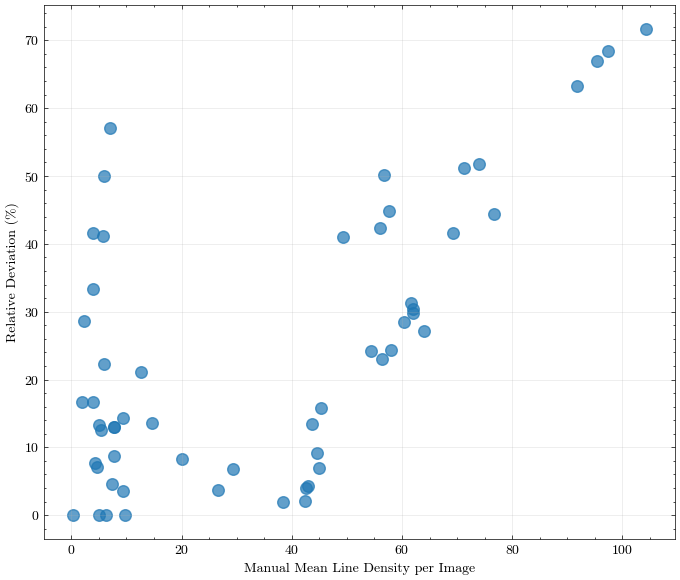

In [21]:
import numpy as np, matplotlib.pyplot as plt

# ---- Compute relative deviation ----
merged_all_sets["rel_dev_manual_vs_model"] = (
    (merged_all_sets["manual_mean_line_density_image"] - merged_all_sets["mean_line_density_image"]).abs()
    / merged_all_sets["manual_mean_line_density_image"]
)

# ---- Extract variables ----
x = merged_all_sets["manual_mean_line_density_image"]
y = merged_all_sets["rel_dev_manual_vs_model"] * 100  # convert to %

# ---- Create scatter plot ----
plt.figure(figsize=(7, 6))
plt.scatter(x, y, s=70, color="tab:blue", alpha=0.7)

# ---- Fit regression line ----
if len(merged_all_sets) > 1:
    coef = np.polyfit(x, y, 1)
    poly_fn = np.poly1d(coef)
    plt.plot(np.sort(x), poly_fn(np.sort(x)), "--", color="black", linewidth=2)

# ---- Labels & formatting ----
plt.xlabel("Manual Mean Line Density per Image")
plt.ylabel("Relative Deviation (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# blind noise estimate the images 

In [24]:
def estimate_noise_wavelet(image, wavelet='db1'):
    """Compute noise estimate using wavelet high-frequency coefficients."""
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    coeffs = pywt.wavedec2(image.astype(np.float32), wavelet=wavelet, level=1)
    _, (cH, cV, cD) = coeffs
    sigma = np.median(np.abs(cD)) / 0.6745
    return sigma

def compute_noise_for_png_folder(folder_path):
    """Evaluate wavelet-based noise for all PNG images in folder."""
    results = []

    for filename in tqdm(os.listdir(folder_path)):
        if filename.lower().endswith(".png"):
            filepath = os.path.join(folder_path, filename)
            image = cv2.imread(filepath, cv2.IMREAD_UNCHANGED)

            if image is None:
                print(f"Warning: Failed to load {filename}, skipping.")
                continue

            noise_std = estimate_noise_wavelet(image)

            results.append({
                "filename": filename,
                "noise_std": noise_std
            })

    df = pd.DataFrame(results)
    return df

# === Usage ===
local_images_dir = NOTEBOOK_DIR / "AFM_KI_tool" / "images"
folder_path = local_images_dir if local_images_dir.exists() else PATHS.test_images_root
df_noise = compute_noise_for_png_folder(folder_path)

df_noise


100%|██████████| 28/28 [00:00<00:00, 659.34it/s]


,filename,noise_std
0,400-1605-W7_map_00033_cropped_1_1.png,17.049668
1,400-1605-W7_map_00033_cropped_1_2.png,17.049678
2,400-1605-W7_map_00033_cropped_2_1.png,17.049669
3,400-1605-W7_map_00033_cropped_2_2.png,17.049669
4,400-1605-W7_map_00051_cropped_1_1.png,20.014826
5,400-1605-W7_map_00051_cropped_1_2.png,17.049669
6,400-1605-W7_map_00051_cropped_2_1.png,20.756113
7,400-1605-W7_map_00051_cropped_2_2.png,20.756114
8,400-1685-W5_map_00004_cropped_1_1.png,25.945145
9,400-1685-W5_map_00004_cropped_1_2.png,25.945145


,filename,run_nbr,mean_58,manual_mean58,mean_117,manual_mean117,mean_187,manual_mean187,mean_line_density_image,mean_line_density_KI,manual_mean_line_density_image,noise_std,line_density_per_micrometer,line_density_per_micrometer_KI,manual_line_density_per_micrometer,dataset_type
0,400-1605-W7_map_00033_cropped_1_1.png,33,36.4,47,40.8,44,36.2,40,37.800,36.976562,43.666667,17.049668,7.560,7.395313,8.733333,high_density
1,400-1605-W7_map_00033_cropped_1_2.png,33,36.4,44,43.8,38,45.4,53,41.867,38.546875,45.000000,17.049678,8.373,7.709375,9.000000,high_density
2,400-1605-W7_map_00033_cropped_2_1.png,33,35.6,39,42.6,46,45.2,44,41.133,39.195312,43.000000,17.049669,8.227,7.839062,8.600000,high_density
3,400-1605-W7_map_00033_cropped_2_2.png,33,44.8,41,41.0,46,38.6,40,41.467,38.871094,42.333333,17.049669,8.293,7.774219,8.466667,high_density
4,400-1605-W7_map_00051_cropped_1_1.png,51,39.6,50,39.4,55,44.6,58,41.200,43.796875,54.333333,20.014826,8.240,8.759375,10.866667,high_density
5,400-1605-W7_map_00051_cropped_1_2.png,51,42.2,67,41.2,66,47.2,53,43.533,43.687500,62.000000,17.049669,8.707,8.737500,12.400000,high_density
6,400-1605-W7_map_00051_cropped_2_1.png,51,38.4,55,47.8,57,45.4,62,43.867,46.449219,58.000000,20.756113,8.773,9.289844,11.600000,high_density
7,400-1605-W7_map_00051_cropped_2_2.png,51,43.8,63,46.8,65,49.2,64,46.600,46.710938,64.000000,20.756114,9.320,9.342187,12.800000,high_density
8,400-1685-W5_map_00004_cropped_1_1.png,4,35.2,55,28.6,58,33.0,55,32.267,30.105469,56.000000,25.945145,6.453,6.021094,11.200000,high_density
9,400-1685-W5_map_00004_cropped_1_2.png,4,30.6,66,29.6,47,35.2,60,31.800,29.277344,57.666667,25.945145,6.360,5.855469,11.533333,high_density


C:\Users\abd93000\AppData\Local\Temp\ipykernel_32712\1750103870.py:54: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  plt.tight_layout()
C:\Users\abd93000\AppData\Local\Temp\ipykernel_32712\1750103870.py:54: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  plt.tight_layout()
c:\Users\abd93000\PycharmProjects\cnt_project_v2\.venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\abd93000\PycharmProjects\cnt_project_v2\.venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


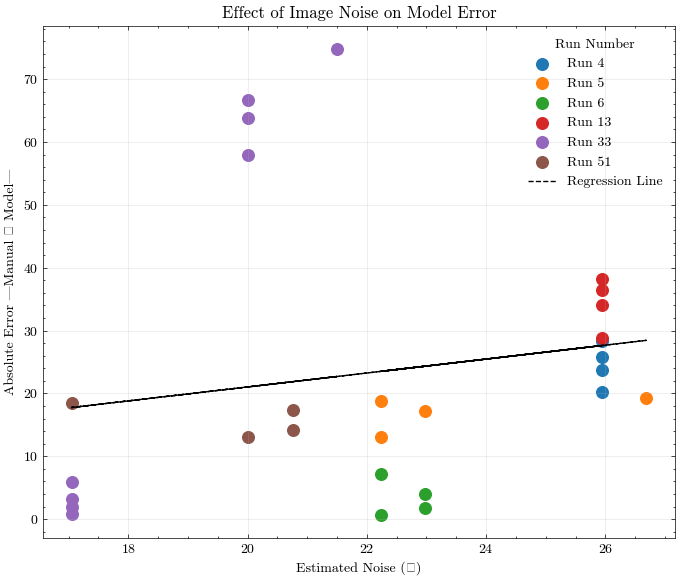

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\misc\high_density_analysis_martin\merged_line_density_with_noise.csv


In [25]:
# Merge noise column into main table
merged_with_noise = merged_final.merge(df_noise, on="filename", how="left")

col_order = [
    "filename", "run_nbr",
    "mean_58", "manual_mean58",
    "mean_117", "manual_mean117",
    "mean_187", "manual_mean187",
    "mean_line_density_image", "mean_line_density_KI", "manual_mean_line_density_image",
    "noise_std",
    "line_density_per_micrometer", "line_density_per_micrometer_KI", "manual_line_density_per_micrometer"
]

# Keep any additional columns automatically at the end
other_cols = [c for c in merged_with_noise.columns if c not in col_order]
merged_with_noise = merged_with_noise[col_order + other_cols]

display(merged_with_noise)

# Compute absolute error if not already computed
merged_with_noise["abs_error_manual_vs_model"] = (
    (merged_with_noise["manual_mean_line_density_image"] -
     merged_with_noise["mean_line_density_image"]).abs()
)

# Extract variables
x = merged_with_noise["noise_std"]
y = merged_with_noise["abs_error_manual_vs_model"]
runs = merged_with_noise["run_nbr"].astype(int)

# Assign categorical colors per run number
unique_runs = sorted(runs.unique())
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
          "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
run_color_map = {run: colors[i % len(colors)] for i, run in enumerate(unique_runs)}

# Create scatter plot
plt.figure(figsize=(7, 6))
for run in unique_runs:
    idx = runs == run
    plt.scatter(x[idx], y[idx], s=70, label=f"Run {run}", color=run_color_map[run])

# Fit regression line across all points
coef = np.polyfit(x, y, 1)
poly_fn = np.poly1d(coef)
plt.plot(x, poly_fn(x), "--", color="black", label="Regression Line")

# Labels & formatting
plt.xlabel("Estimated Noise (σ)")
plt.ylabel("Absolute Error |Manual − Model|")
plt.title("Effect of Image Noise on Model Error")
plt.grid(alpha=0.3)
plt.legend(title="Run Number")
plt.tight_layout()
plt.show()

noise_table_output = OUTPUT_DIR / "merged_line_density_with_noise.csv"
merged_with_noise.to_csv(noise_table_output, index=False)
print(f"Saved: {noise_table_output}")

# Peak detection line density counter

Detected peak indices (including edges if valid): [  5  15  20  29  33  42  50  53  55  61  64  71  76  87  93  96 105 107
 114 123 129 131 133 137 141 153 158 164 168 170 174 180 184 187 207 210
 215 220 223 228 232 244 250 255]
Peak intensities: [248 246 183 127 185 120 133 147 132 255 150 147 145 146 143 185 107  98
 195 132 106 134 162 130 255 113 176  86 120 205 167 121  97 197 124 217
 122 135 163 103 197 136 135 149]
Number of peaks detected: 44


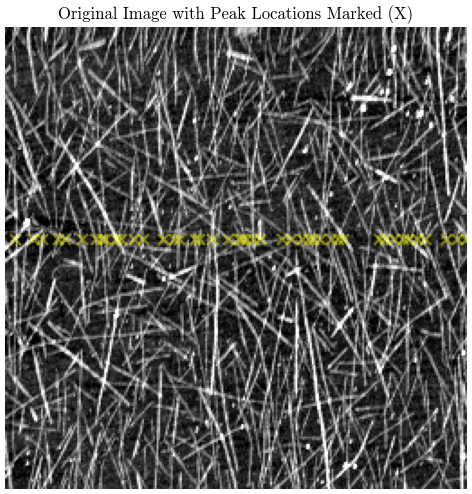

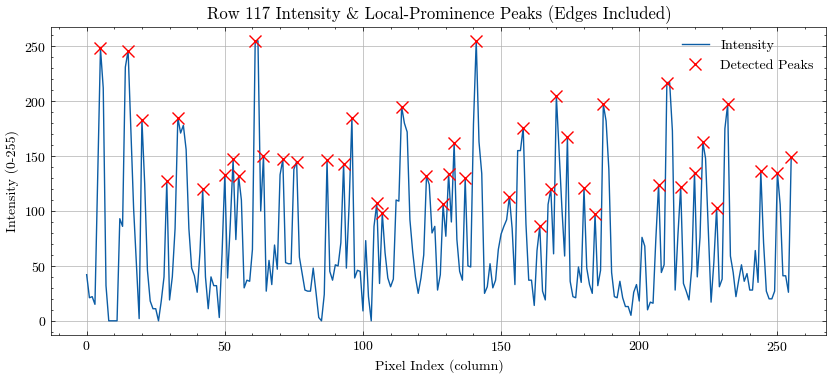

In [27]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# ---------------- CONFIG ----------------
image_name = "400-1605-W7_map_00051_cropped_1_1.png"
local_image_path = NOTEBOOK_DIR / "AFM_KI_tool" / "images" / image_name
dataset_image_path = PATHS.test_images_root / image_name
if local_image_path.exists():
    image_path = local_image_path
elif dataset_image_path.exists():
    image_path = dataset_image_path
else:
    raise FileNotFoundError(f"Could not locate image in local assets or dataset: {image_name}")

row_index = 117 # 58, 117, 187
apply_smoothing = False
smoothing_sigma = 2
peak_distance= 2
peak_prominence = 10         # How much peak stands above neighbors
min_peak_height = 80         # Minimum height (intensity) of peak

# ---------------- LOAD IMAGE ----------------
img = cv2.imread(str(image_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ---------------- EXTRACT SIGNAL ----------------
row_values = img_gray[row_index, :]

if apply_smoothing:
    row_values_smoothed = gaussian_filter1d(row_values, sigma=smoothing_sigma)
else:
    row_values_smoothed = row_values

# ---------------- LOCAL PEAK DETECTION ----------------
peaks, properties = find_peaks(
    row_values_smoothed,
    prominence=peak_prominence,
    height=min_peak_height,
    distance=peak_distance
)

# ----------- MANUAL EDGE PEAK CHECK -----------
edge_peaks = []

# Check first value
if row_values_smoothed[0] >= min_peak_height and row_values_smoothed[0] > row_values_smoothed[1]:
    edge_peaks.append(0)

# Check last value
if row_values_smoothed[-1] >= min_peak_height and row_values_smoothed[-1] > row_values_smoothed[-2]:
    edge_peaks.append(len(row_values_smoothed) - 1)

# Combine edge peaks with scipy peaks
if edge_peaks:
    peaks = np.concatenate([peaks, edge_peaks])
    peaks = np.sort(peaks)

print(f"Detected peak indices (including edges if valid): {peaks}")
print(f"Peak intensities: {row_values_smoothed[peaks]}")
print(f"Number of peaks detected: {len(peaks)}")

# ---------------- DISPLAY IMAGE + PEAK OVERLAY ----------------
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)

# Plot only X markers (no horizontal line)
for col in peaks:
    plt.scatter(col, row_index, marker='x', color='yellow', s=60, linewidths=2, alpha=0.4)

plt.title("Original Image with Peak Locations Marked (X)")
plt.axis('off')
plt.show()

# ---------------- PLOT SIGNAL + PEAKS ----------------
plt.figure(figsize=(10,4))
plt.plot(row_values_smoothed, label="Smoothed Intensity" if apply_smoothing else "Intensity")
plt.plot(peaks, row_values_smoothed[peaks], "rx", markersize=8, label="Detected Peaks")
plt.title(f"Row {row_index} Intensity & Local-Prominence Peaks (Edges Included)")
plt.xlabel("Pixel Index (column)")
plt.ylabel("Intensity (0-255)")
plt.legend()
plt.grid(True)
plt.show()
